In [2]:
# Variables
DATASET_PATH = 'flwrlabs/fed-isic2019'
LABELS = list(map(str, range(8)))
GROUP_COL = 'center'

In [3]:
import eda_helpers as eda
model = eda.models.densenet121(weights=None)
model.classifier = eda.nn.Linear(model.classifier.in_features, len(LABELS))

model.load_state_dict(eda.torch.load('/home/kpetrenko/work/models/skin'))


/home/kpetrenko/work/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [6]:
import importlib

importlib.reload(eda)


<module 'eda_helpers' from '/home/kpetrenko/work/third_attempt/EDA/eda_helpers.py'>

In [4]:
transform = eda.transforms.Compose([
        eda.transforms.ToTensor(),
        eda.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
import psutil
device = eda.torch.device('cpu')
eda.torch.set_num_threads(min(20, psutil.cpu_count()))

correct per cent:  0.6610752688172044


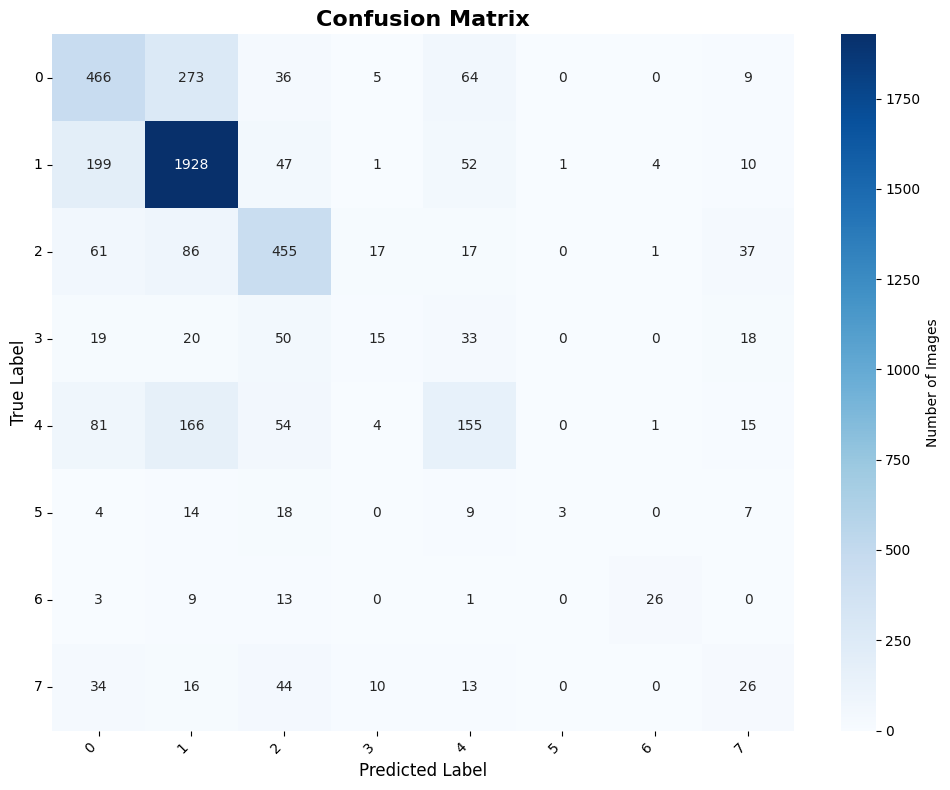

array([[ 466,  273,   36,    5,   64,    0,    0,    9],
       [ 199, 1928,   47,    1,   52,    1,    4,   10],
       [  61,   86,  455,   17,   17,    0,    1,   37],
       [  19,   20,   50,   15,   33,    0,    0,   18],
       [  81,  166,   54,    4,  155,    0,    1,   15],
       [   4,   14,   18,    0,    9,    3,    0,    7],
       [   3,    9,   13,    0,    1,    0,   26,    0],
       [  34,   16,   44,   10,   13,    0,    0,   26]])

In [7]:
data_test = eda.download_dataset(DATASET_PATH, 'test')
data_test['image'] = data_test['image'].map(lambda x: eda.resize_and_pad(x, (224, 224)))

val_test = eda.DataFrameImageDataset(data_test, "image", "label", transform)
val_loader = eda.DataLoader(val_test, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
predictions, targets, probabilities = eda.evaluate_model(model, val_loader, device)
cm = eda.plot_confusion_matrix(targets, predictions, LABELS)
display(cm)

0:


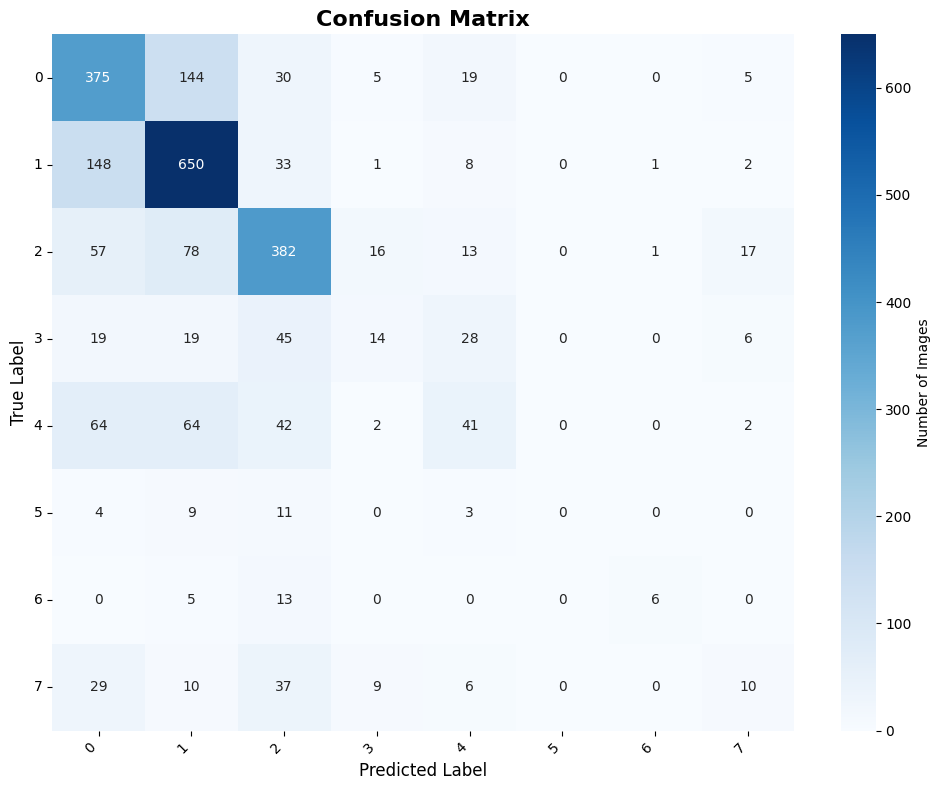

array([[375, 144,  30,   5,  19,   0,   0,   5],
       [148, 650,  33,   1,   8,   0,   1,   2],
       [ 57,  78, 382,  16,  13,   0,   1,  17],
       [ 19,  19,  45,  14,  28,   0,   0,   6],
       [ 64,  64,  42,   2,  41,   0,   0,   2],
       [  4,   9,  11,   0,   3,   0,   0,   0],
       [  0,   5,  13,   0,   0,   0,   6,   0],
       [ 29,  10,  37,   9,   6,   0,   0,  10]])

1:


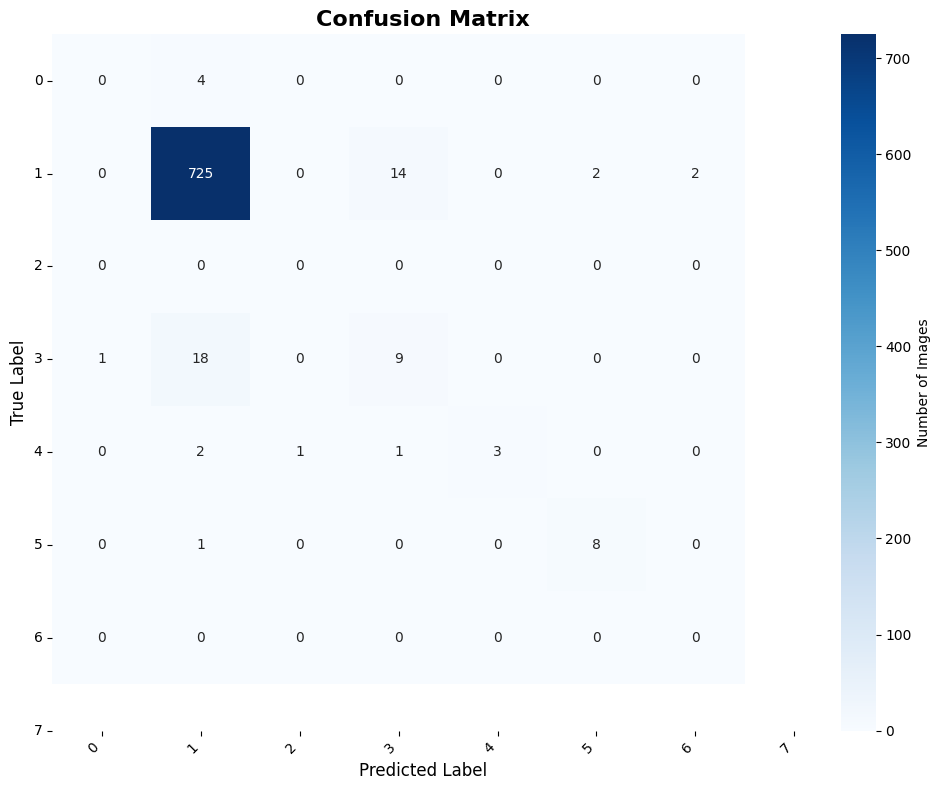

array([[  0,   4,   0,   0,   0,   0,   0],
       [  0, 725,   0,  14,   0,   2,   2],
       [  0,   0,   0,   0,   0,   0,   0],
       [  1,  18,   0,   9,   0,   0,   0],
       [  0,   2,   1,   1,   3,   0,   0],
       [  0,   1,   0,   0,   0,   8,   0],
       [  0,   0,   0,   0,   0,   0,   0]])

2:


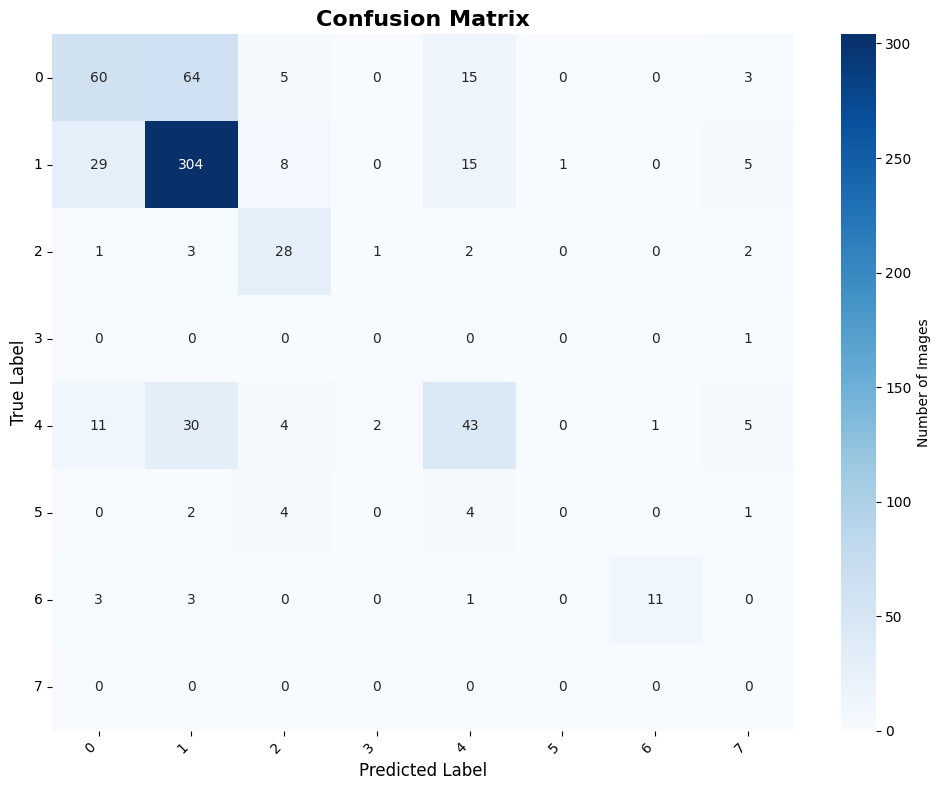

array([[ 60,  64,   5,   0,  15,   0,   0,   3],
       [ 29, 304,   8,   0,  15,   1,   0,   5],
       [  1,   3,  28,   1,   2,   0,   0,   2],
       [  0,   0,   0,   0,   0,   0,   0,   1],
       [ 11,  30,   4,   2,  43,   0,   1,   5],
       [  0,   2,   4,   0,   4,   0,   0,   1],
       [  3,   3,   0,   0,   1,   0,  11,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0]])

3:


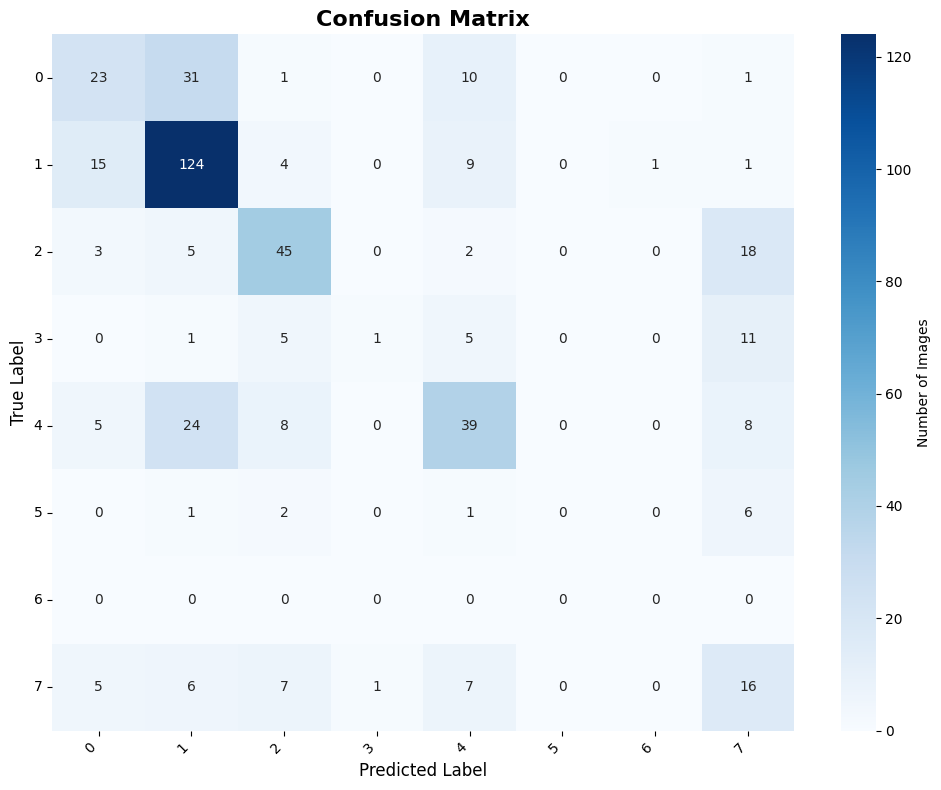

array([[ 23,  31,   1,   0,  10,   0,   0,   1],
       [ 15, 124,   4,   0,   9,   0,   1,   1],
       [  3,   5,  45,   0,   2,   0,   0,  18],
       [  0,   1,   5,   1,   5,   0,   0,  11],
       [  5,  24,   8,   0,  39,   0,   0,   8],
       [  0,   1,   2,   0,   1,   0,   0,   6],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [  5,   6,   7,   1,   7,   0,   0,  16]])

4:


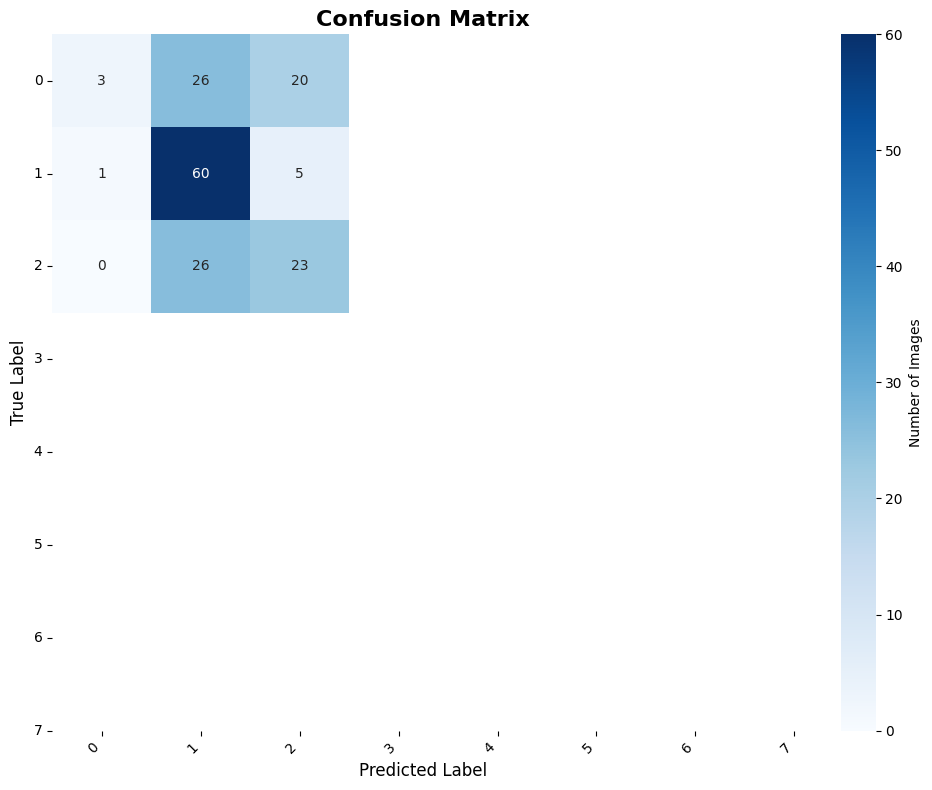

array([[ 3, 26, 20],
       [ 1, 60,  5],
       [ 0, 26, 23]])

5:


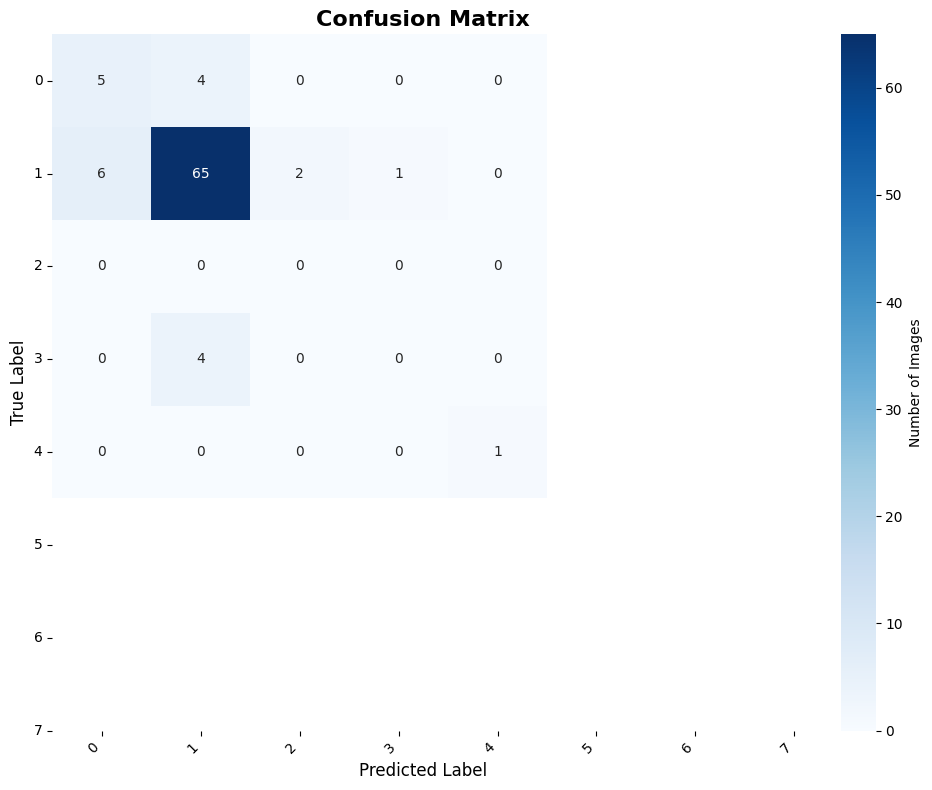

array([[ 5,  4,  0,  0,  0],
       [ 6, 65,  2,  1,  0],
       [ 0,  0,  0,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  0,  0,  1]])

In [6]:
DOMAIN = data_test.center.unique()
for domain in DOMAIN:
    print(domain, end=':\n')
    val_test = eda.DataFrameImageDataset(data_test[data_test[GROUP_COL] == domain], "image", "label", transform)
    val_loader = eda.DataLoader(val_test, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)
    
    
    predictions, targets, probabilities = eda.evaluate_model(model, val_loader, device)
    cm = eda.plot_confusion_matrix(targets, predictions, LABELS)
    display(cm)

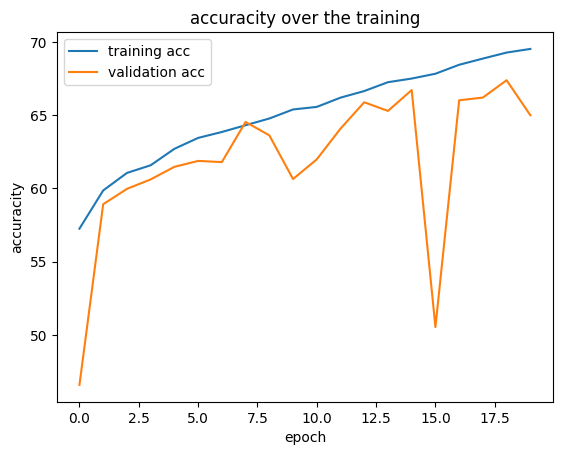

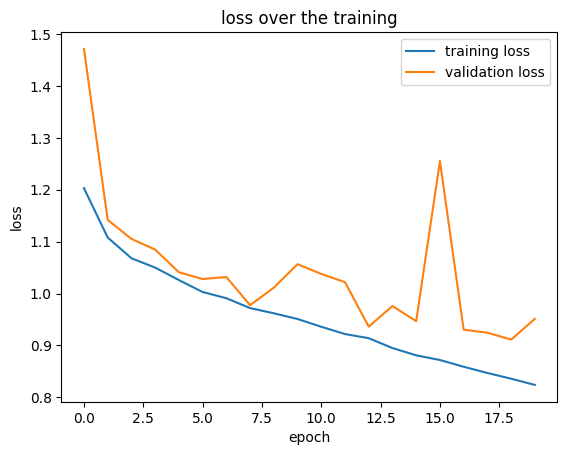

In [7]:
import json
with open("/home/kpetrenko/work/models/skin_progress", 'r') as f:
    training_acc = json.loads(f.readline())

    validation_acc =  json.loads(f.readline())

    training_loss = json.loads(f.readline())

    validation_loss = json.loads(f.readline())


eda.draw_model_training_process(training_acc, validation_acc, training_loss, validation_loss)